[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/weaviate/recipes/blob/main/weaviate-features/quantization/rotational-quantization-rq4.ipynb)

# 4-bit Rotational Quantization (RQ4) with Centering

*Weaviate version `1.40.0` · Weaviate Python client `4.23.1` · Cohere `embed-multilingual-v3.0` vectors — by Duda Nogueira ([Weaviate](https://weaviate.io))*

[Rotational Quantization (RQ)](https://docs.weaviate.io/weaviate/configuration/compression/rq-compression) compresses each vector so the vector index needs far less memory. Plain RQ needs no training step and works with any embedding model.

| Setting | Bytes per 1024-dim vector | Compression |
|---|---|---|
| No compression (float32) | 4,096 | 1× |
| RQ, 8 bits | 1,040 | ~4× |
| RQ, 4 bits | 528 | ~7.8× |
| RQ, 4 bits, **centered** (new in v1.40) | 528 | ~7.8× |

**Centering** improves 4-bit RQ at no extra space: Weaviate fits the mean of your vectors, encodes each vector relative to that mean, and stores the two largest coordinates of each vector exactly. This helps most when embeddings all point in roughly the same direction, which is common for text embedding models.

In this recipe we compress 49,500 real Cohere embeddings four ways and measure recall against exact search.

In [1]:
!pip install -Uq "weaviate-client>=4.23.1" huggingface_hub pyarrow matplotlib

## 1. Load pre-vectorized data

We download two files from [`weaviate/wiki-sample`](https://huggingface.co/datasets/weaviate/wiki-sample): 50,000 Wikipedia passages already embedded with Cohere `embed-multilingual-v3.0` (1024 dimensions). No API key is needed.

We keep the last 500 vectors aside as **queries**, and index the other 49,500.

In [2]:
import numpy as np
import pyarrow.parquet as pq
from huggingface_hub import hf_hub_download

files = [
    hf_hub_download("weaviate/wiki-sample", f"cohere/embed-multilingual-v3/{i:04d}.parquet", repo_type="dataset")
    for i in (1, 2)
]
vectors = np.vstack([
    np.array(pq.read_table(f, columns=["vector"]).column("vector").to_pylist(), dtype=np.float32)
    for f in files
])

N_QUERIES = 500
data, queries = vectors[:-N_QUERIES], vectors[-N_QUERIES:]
print("Indexed vectors:", data.shape, "| Queries:", queries.shape)

Indexed vectors: (49500, 1024) | Queries: (500, 1024)


## 2. Compute the exact answers

To measure recall, we need the true 10 nearest neighbors of every query. With 49,500 vectors, an exact cosine search in NumPy takes a second.

In [3]:
def normalize(x):
    return x / np.linalg.norm(x, axis=1, keepdims=True)


K = 10
ground_truth = np.argsort(-(normalize(queries) @ normalize(data).T), axis=1)[:, :K]
ground_truth.shape

(500, 10)

## 3. Start an embedded Weaviate with async indexing

We turn on **asynchronous indexing** (`ASYNC_INDEXING=true`). Centered RQ needs it: Weaviate first collects `training_limit` vectors (10,000 by default) to fit the mean, then compresses the index in the background. Without async indexing, a centered index stays uncompressed.

In [4]:
import weaviate

client = weaviate.connect_to_embedded(
    version="1.40.0",
    environment_variables={"LOG_LEVEL": "error", "ASYNC_INDEXING": "true"},
)

print("Weaviate version:", client.get_meta()["version"])

Weaviate version: 1.40.0


## 4. Helpers

- `create_and_load()` creates a collection with a given quantizer, imports the vectors, and waits until async indexing has finished and the index is compressed. We read the shard status with `client.cluster.nodes()`.
- `measure()` runs the 500 queries and returns recall@10 and the average query latency.

In [5]:
import time
from weaviate.classes.config import Configure, DataType, Property


def shard_status(collection_name):
    nodes = client.cluster.nodes(collection=collection_name, output="verbose")
    return nodes[0].shards[0]  # single node, single shard


def create_and_load(name, quantizer=None):
    client.collections.delete(name)
    collection = client.collections.create(
        name,
        properties=[Property(name="row", data_type=DataType.INT)],
        vector_config=Configure.Vectors.self_provided(
            vector_index_config=Configure.VectorIndex.hnsw(quantizer=quantizer),
        ),
    )
    with collection.batch.fixed_size(batch_size=1000) as batch:
        for row, vector in enumerate(data):
            batch.add_object({"row": row}, vector=vector)
    assert not collection.batch.failed_objects

    # Wait for async indexing to finish and, if a quantizer is set, for compression
    while True:
        status = shard_status(name)
        indexed = status.vector_queue_length == 0 and status.vector_indexing_status == "READY"
        if indexed and (quantizer is None or status.compressed):
            return collection
        time.sleep(2)


def measure(collection):
    hits, start = 0, time.time()
    for query, truth in zip(queries, ground_truth):
        response = collection.query.near_vector(query, limit=K, return_properties=["row"])
        hits += len({o.properties["row"] for o in response.objects} & set(truth.tolist()))
    return hits / (len(queries) * K), (time.time() - start) / len(queries) * 1000

## 5. Raw quality of each compression

By default, HNSW **rescores** its final candidates with the original, uncompressed vectors read from disk. That hides most of the compression error, which is great in production but makes it hard to compare quantizers.

So first we turn rescoring off with `rescore_limit=0`. This shows how good the compressed vectors are on their own.

In [6]:
Quantizer = Configure.VectorIndex.Quantizer

raw_configs = {
    "NoCompression": None,
    "RQ8": Quantizer.rq(bits=8, rescore_limit=0),
    "RQ4": Quantizer.rq(bits=4, rescore_limit=0),
    "RQ4Centered": Quantizer.rq(bits=4, centering=True, rescore_limit=0),
}

raw_results = {}
for name, quantizer in raw_configs.items():
    collection = create_and_load(name, quantizer)
    raw_results[name] = measure(collection)
    print(f"{name:14} recall@10={raw_results[name][0]:.4f}  query={raw_results[name][1]:.1f} ms")

NoCompression  recall@10=0.9948  query=1.6 ms


RQ8            recall@10=0.9900  query=0.8 ms


RQ4            recall@10=0.9526  query=0.7 ms


RQ4Centered    recall@10=0.9596  query=0.7 ms


Without rescoring, 4-bit codes lose some recall compared to 8-bit ones, and **centering recovers part of that loss at the same size**.

## 6. Quality with rescoring (the default)

Now the same quantizers with their default settings, which rescore the top candidates with the full vectors:

In [7]:
default_configs = {
    "RQ8Default": Quantizer.rq(bits=8),
    "RQ4Default": Quantizer.rq(bits=4),
    "RQ4CenteredDefault": Quantizer.rq(bits=4, centering=True),
}

default_results = {"NoCompression": raw_results["NoCompression"]}
for name, quantizer in default_configs.items():
    collection = create_and_load(name, quantizer)
    default_results[name] = measure(collection)
    print(f"{name:20} recall@10={default_results[name][0]:.4f}  query={default_results[name][1]:.1f} ms")

RQ8Default           recall@10=0.9954  query=0.8 ms


RQ4Default           recall@10=0.9960  query=0.8 ms


RQ4CenteredDefault   recall@10=0.9960  query=0.8 ms


With rescoring, every option is close to the uncompressed recall. RQ4 keeps the vectors that HNSW traverses **7.8× smaller** than float32, and you barely pay for it in quality.

## 7. Summary

               bytes/vector  recall (raw)  recall (rescored)
NoCompression         4,096        0.9948             0.9948
RQ8                   1,040        0.9900             0.9954
RQ4                     528        0.9526             0.9960
RQ4Centered             528        0.9596             0.9960


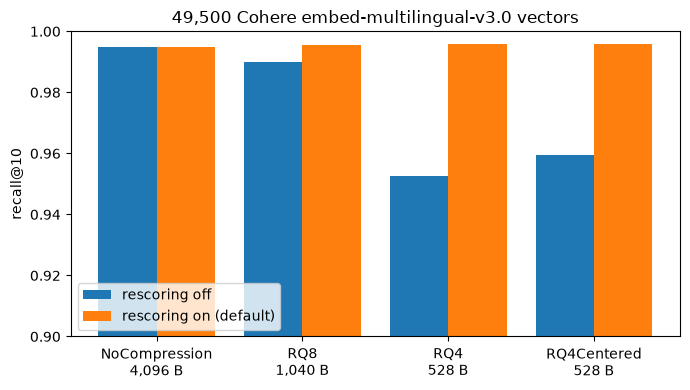

In [8]:
import matplotlib.pyplot as plt

DIM = data.shape[1]
bytes_per_vector = {"NoCompression": DIM * 4, "RQ8": 16 + DIM, "RQ4": 16 + DIM // 2, "RQ4Centered": 16 + DIM // 2}
labels = ["NoCompression", "RQ8", "RQ4", "RQ4Centered"]

print(f"{'':14} {'bytes/vector':>12} {'recall (raw)':>13} {'recall (rescored)':>18}")
for label in labels:
    rescored = default_results["NoCompression" if label == "NoCompression" else f"{label}Default"][0]
    print(f"{label:14} {bytes_per_vector[label]:>12,} {raw_results[label][0]:>13.4f} {rescored:>18.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(labels))
ax.bar(x - 0.2, [raw_results[l][0] for l in labels], 0.4, label="rescoring off")
ax.bar(x + 0.2, [default_results["NoCompression" if l == "NoCompression" else f"{l}Default"][0] for l in labels], 0.4, label="rescoring on (default)")
ax.set_xticks(x, [f"{l}\n{bytes_per_vector[l]:,} B" for l in labels])
ax.set_ylim(0.9, 1.0)
ax.set_ylabel("recall@10")
ax.set_title("49,500 Cohere embed-multilingual-v3.0 vectors")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Good to know

- **Enable it:** `Configure.VectorIndex.Quantizer.rq(bits=4, centering=True)`, on an HNSW index.
- **Centering needs async indexing** (`ASYNC_INDEXING=true`). The index compresses once `training_limit` vectors (10,000 by default) have been indexed. Check the `compressed` flag of the shard with `client.cluster.nodes(output="verbose")`.
- **4 bits only.** Centering is only available with `bits=4`. Flat indexes support RQ with 1 or 8 bits.
- **Immutable.** You can't turn centering on or off on an existing index.
- **No downgrade.** Weaviate versions before 1.40 can't read a centered index.
- **Not for multi-vector indexes.**

Learn more about [RQ in the Weaviate docs](https://docs.weaviate.io/weaviate/configuration/compression/rq-compression).

In [9]:
client.close()